### 2c) finding diverted rate and defining features that make up model 

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import matplotlib.ticker as ticker

In [2]:
# Reading the data & combining the years data into flights_df dataframe
years = range(2004, 2009)
file_names = [f"{year}.csv.bz2" for year in years]

# Load and concatenate flight data without filtering
chunks = []
for fname, year in zip(file_names, years):
    chunk = pd.read_csv(fname, low_memory = False).assign(Year = year)
    chunks.append(chunk)

flights_df = pd.concat(chunks, ignore_index = True)


In [3]:
# Reading the planes-data.csv data
planes_df = pd.read_csv("plane-data.csv", keep_default_na=False)

In [4]:
# Trimming empty spaces and conveerting blank strings to Na
str_cols = planes_df.select_dtypes(include=['object', 'string']).columns
planes_df[str_cols] = planes_df[str_cols].apply(lambda col: col.str.strip())
planes_df.replace('', np.nan, inplace=True)

,tailnum,type,manufacturer,issue_date,model,status,aircraft_type,engine_type,year
0,N050AA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N051AA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N052AA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N054AA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N055AA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
5024,N997DL,Corporation,MCDONNELL DOUGLAS AIRCRAFT CO,03/11/1992,MD-88,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1992
5025,N998AT,Corporation,BOEING,01/23/2003,717-200,Valid,Fixed Wing Multi-Engine,Turbo-Fan,2002
5026,N998DL,Corporation,MCDONNELL DOUGLAS CORPORATION,04/02/1992,MD-88,Valid,Fixed Wing Multi-Engine,Turbo-Jet,1992
5027,N999CA,Foreign Corporation,CANADAIR,07/09/2008,CL-600-2B19,Valid,Fixed Wing Multi-Engine,Turbo-Jet,1998


In [5]:
# Removing rows with NaN values
planes_df.dropna(inplace=True)
planes_df.head()

,tailnum,type,manufacturer,issue_date,model,status,aircraft_type,engine_type,year
34,N10156,Corporation,EMBRAER,02/13/2004,EMB-145XR,Valid,Fixed Wing Multi-Engine,Turbo-Fan,2004
35,N102UW,Corporation,AIRBUS INDUSTRIE,05/26/1999,A320-214,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1998
36,N10323,Corporation,BOEING,07/01/1997,737-3TO,Valid,Fixed Wing Multi-Engine,Turbo-Jet,1986
37,N103US,Corporation,AIRBUS INDUSTRIE,06/18/1999,A320-214,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1999
38,N104UA,Corporation,BOEING,01/26/1998,747-422,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1998


In [6]:
# Removing rows with NA issue dates
planes_df.loc[planes_df['year'].isin(['None', '0000']), 'year'] = np.nan
planes_df['year'] = pd.to_numeric(planes_df['year'], errors='coerce')
planes_df = planes_df[
    (planes_df['year'].notna())
]

In [7]:
# Converting issue_date to datetime format, year to numeric & renaming tailnum to TailNum
planes_df = planes_df.rename(columns = {'tailnum': 'TailNum'})

In [8]:
# Imorting additional libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import plotly.express as px
import statsmodels.api as sm
from scipy.special import expit
import plotly.graph_objects as go
from statsmodels.tools import add_constant
from matplotlib.ticker import PercentFormatter

In [9]:
# Reading the carriers and airports data
carriers_df = pd.read_csv("carriers.csv", keep_default_na=False)
airports_df = pd.read_csv("airports.csv", keep_default_na=False)

In [10]:
# Convert Diverted to categorical
flights_df['Diverted'] = flights_df['Diverted'].astype('category')

# Filter out cancelled flights
div_df = flights_df[
    (
        (flights_df['Cancelled'] == 0) &
        (flights_df['Diverted'] == 0) &
        (flights_df['DepTime'] < 2400) &
        (flights_df['ArrTime'] < 2400)
    ) |
    (flights_df['Diverted'] == 1)
]

In [11]:
# Calculating the proportion of diverted flights for each year
div_summary = div_df.groupby('Year').agg(
    total_flights = ('Diverted', 'count'),
    div_count = ('Diverted', lambda x: (x == 1).sum())
).reset_index()

div_summary['div_count'] = div_summary['div_count'].astype(int)
div_summary['total_flights'] = div_summary['total_flights'].astype(int)
div_summary['div_percent'] = div_summary['div_count'] / div_summary['total_flights'] * 100

print(div_summary)


   Year  total_flights  div_count  div_percent
0  2004        6993604      13784     0.197094
1  2005        6996456      14028     0.200502
2  2006        7013271      16186     0.230791
3  2007        7289022      17179     0.235683
4  2008        2323620       5654     0.243327


In [11]:
# Merging destination airport coordinates into div_df for mapping
filtered_airports = airports_df[['iata', 'lat', 'long']]
div_df = div_df.merge(filtered_airports, left_on = 'Dest', right_on = 'iata', how = 'left')

In [12]:
# Summarising diverted flights by year and destination airport for map plotting
airport_summary = div_df.groupby(['Year', 'Dest', 'lat', 'long']).agg(
    total_arr = ('Diverted', 'count'),
    div_arrivals = ('Diverted', lambda x: (x == 1).sum())
).reset_index()
airport_summary['div_rate'] = airport_summary['div_arrivals'] / airport_summary['total_arr'] * 100

In [13]:
# Filtering results to top 10 airports by diversion rate per year where total arrivals are at least 50 for better analysis
top_ten_airports = airport_summary[airport_summary['total_arr'] >= 50].sort_values(['Year', 'div_rate'], ascending = [True, False]).groupby('Year').head(10)

In [14]:
# Plotting a map for the top 10 airports by diversion rate for each year 
for year in top_ten_airports['Year'].unique():
    subset = top_ten_airports[top_ten_airports['Year'] == year]
    fig = px.scatter_geo(
        subset,
        lat = 'lat',
        lon = 'long',
        size = 'total_arr',
        color = 'div_rate',
        text = 'Dest',
        title = f"Top 10 US Destination Airports by Diversion Rate ({year})",
        color_continuous_scale = ["green", "yellow", "orange", "red", "darkred"]
    )
    fig.update_geos(
    projection_type="equirectangular",
    lonaxis_range=[-175, -60],
    lataxis_range=[15, 75],
    showland=True,
    landcolor="lightgray",
    showcountries=False,
    showsubunits=True
    )
    fig.show()

In [12]:
# Converting carrier to categorical 
carriers_df['Code'] = carriers_df['Code'].astype('category')


In [13]:
# Renaming carriers column & merging engine_type data from planes_df into flights data remame
div_df.rename(columns = {'UniqueCarrier': 'Code'}, inplace=True)
div_df = div_df.merge(carriers_df[['Code', 'Description']], on = 'Code', how = 'left')

In [14]:
# Renaming the Description column to carrier
div_df.rename(columns = {'Description': 'carrier'}, inplace = True)

In [15]:
# Converting Diverted column to numeric for aggregation
div_df['Diverted'] = pd.to_numeric(div_df['Diverted'], errors='coerce')

In [15]:
# Calculating diversion rates by carrier and year
carrier_div = div_df.groupby(['Year', 'carrier']).agg(
    total_flights=('Diverted', 'size'),
    div_flights = ('Diverted', 'sum')
).reset_index()
carrier_div['div_rate'] = carrier_div['div_flights'] / carrier_div['total_flights']

In [16]:
# Standard error for proportion
carrier_div['se'] = np.sqrt(
    carrier_div['div_rate'] * (1 - carrier_div['div_rate']) / carrier_div['total_flights']
)

In [17]:
# 95% confidence interval
carrier_div['ci_low'] = carrier_div['div_rate'] - 1.96 * carrier_div['se']
carrier_div['ci_high'] = carrier_div['div_rate'] + 1.96 * carrier_div['se']

In [18]:
# Filtering carriers to only include those with at least 50 flights for more reliable diversion rate estimates
carrier_div = carrier_div[carrier_div['total_flights'] >= 50]

In [19]:
# Filtering to get the top 10 carriers by diversion rate for each year
top_div_carriers = (
    carrier_div.sort_values(['Year', 'div_flights'], ascending = [True, False])
    .groupby('Year', group_keys = False)
    .head(10)
    .reset_index(drop = True)
)

In [20]:
# Cleaning long carrier names
top_div_carriers['carrier'] = top_div_carriers['carrier'].str.replace(
    r"US Airways Inc\. \(Merged with America West 9/05\. Reporting for both starting 10/07\.\)",
    "US Airways Inc.",
    regex=True
)

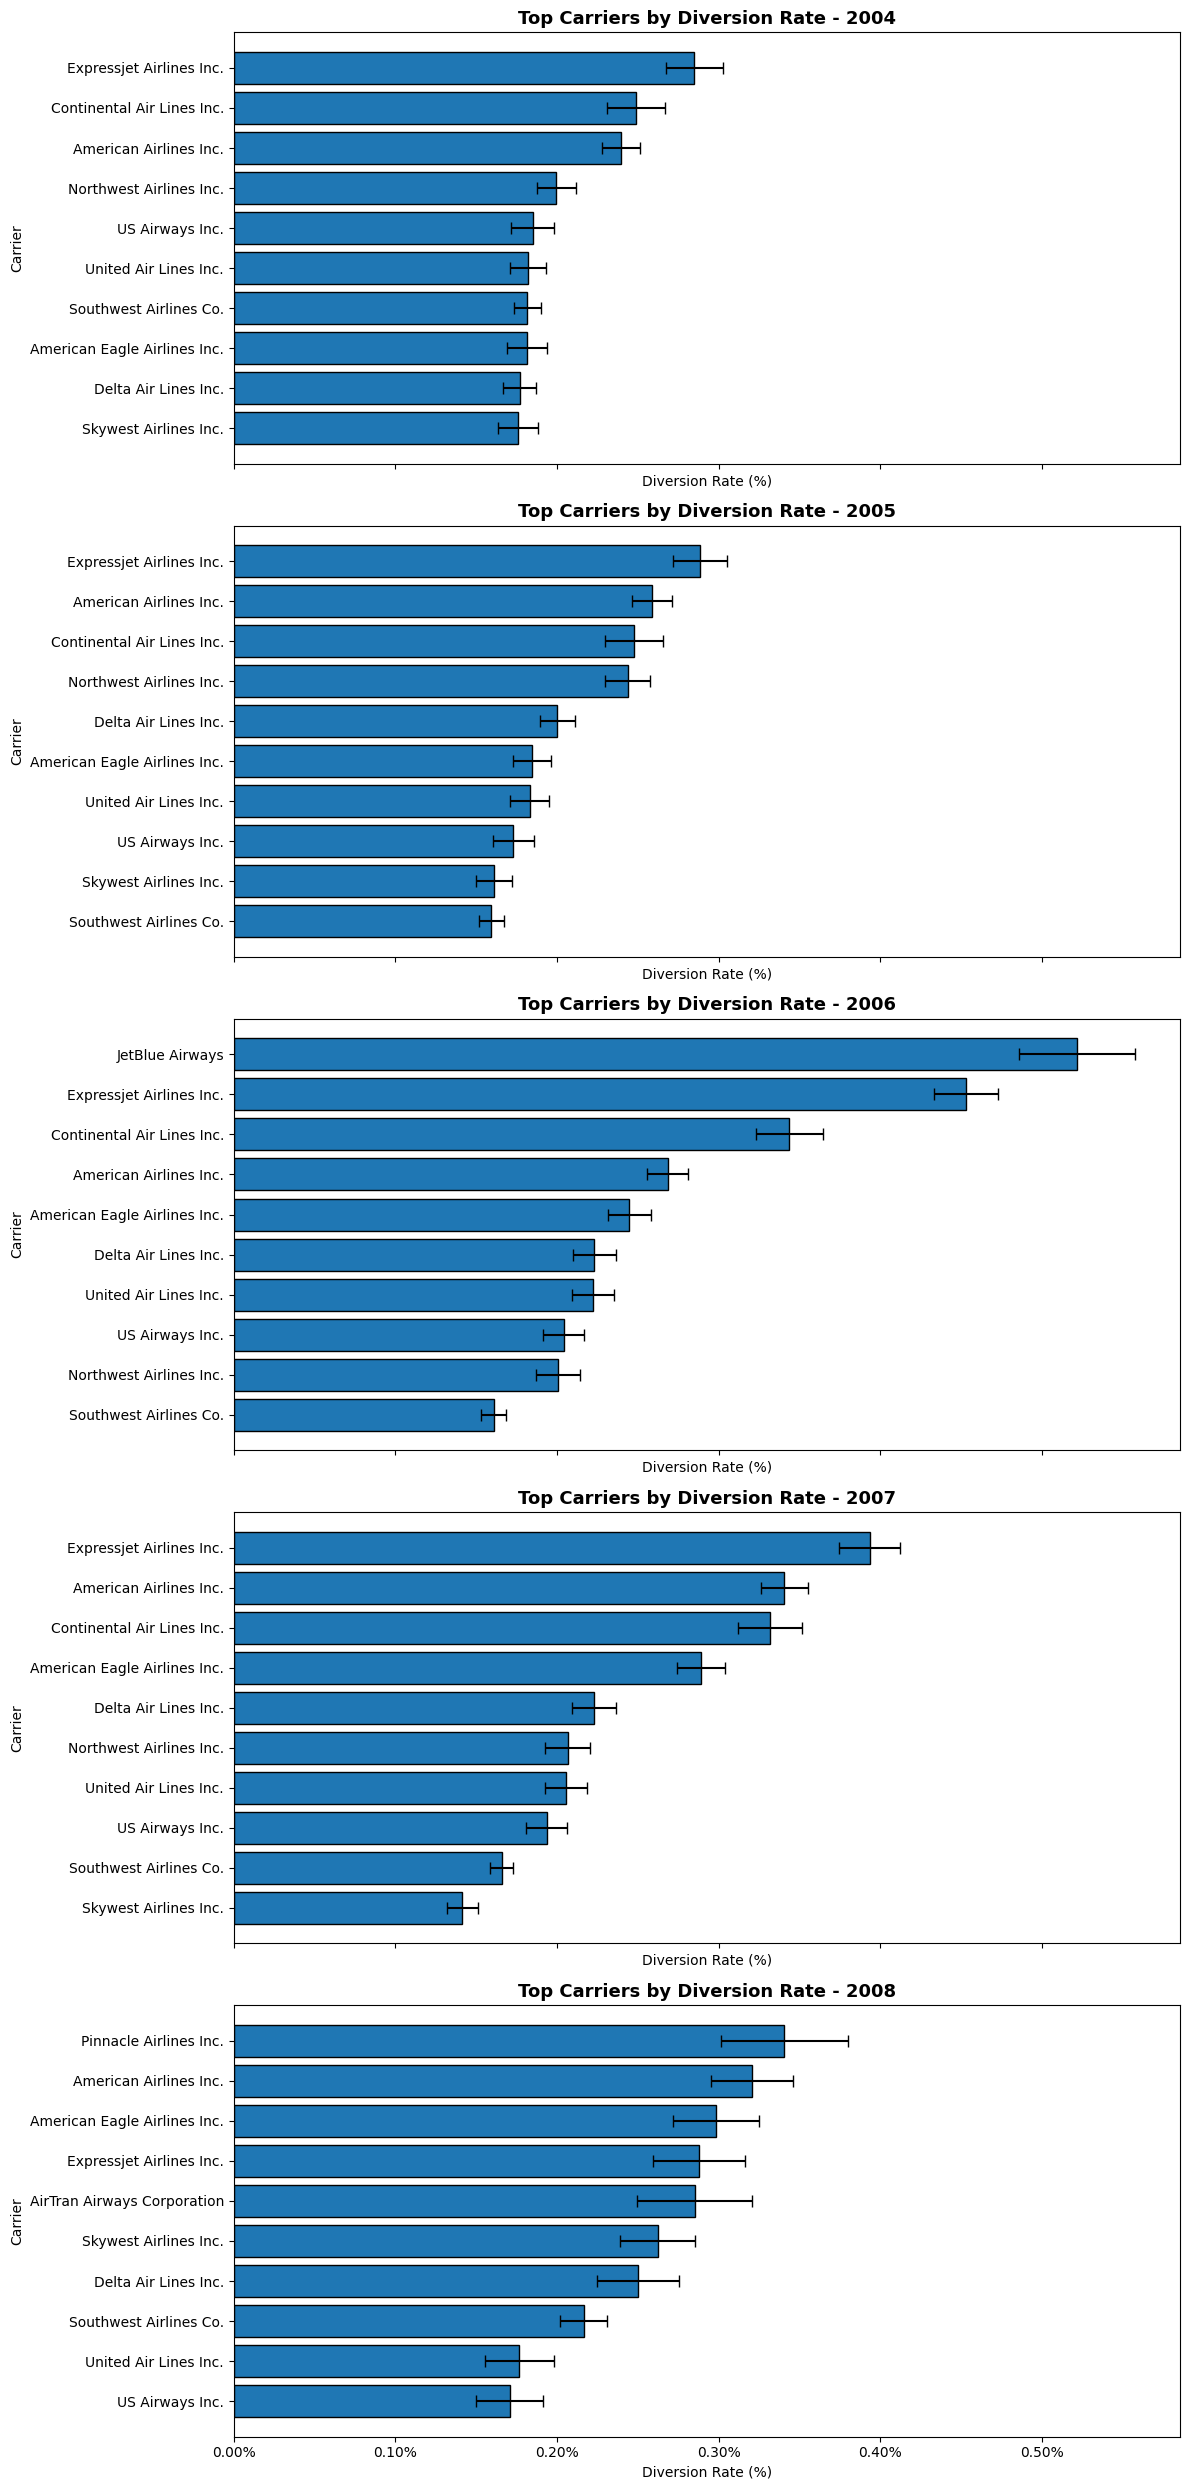

In [ ]:
# Plotting the top 10 carriers by diverted flights for each year
years = sorted(top_div_carriers['Year'].unique())
fig, axes = plt.subplots(nrows = len(years), ncols=1, figsize=(12, 5 * len(years)), sharex = True)

# Handle single year case
if len(years) == 1:
    axes = [axes]

for ax, year in zip(axes, years):
    plot_df = (
        top_div_carriers[top_div_carriers['Year'] == year]
        .sort_values('div_rate', ascending=True)
    )

    ax.barh(
        plot_df['carrier'],
        plot_df['div_rate'],
        xerr=[
            plot_df['div_rate'] - plot_df['ci_low'],
            plot_df['ci_high'] - plot_df['div_rate']
        ],
        capsize=4,
        edgecolor='black'
    )

    # Apply percentage formatting (per axis)
    ax.xaxis.set_major_formatter(PercentFormatter(1))

    ax.set_title(f"Top Carriers by Diversion Rate - {year}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Diversion Rate (%)")
    ax.set_ylabel("Carrier")

plt.tight_layout()
plt.show()

In [16]:
# Extracting CRS departure and arrival hours from div_df for model
div_df['crs_dep_hour'] = div_df['CRSDepTime'] // 100
div_df['crs_arr_hour'] = div_df['CRSArrTime'] // 100

In [17]:
# Replacing hr 24 value with 0 for the scheduled arrival and departure hour columns
div_df["crs_arr_hour"] = div_df["crs_arr_hour"].replace(24, 0)
div_df["crs_dep_hour"] = div_df["crs_dep_hour"].replace(24, 0)

In [18]:
# Adding route column to div_df for inclusion to model 
div_df["route"] = div_df["Origin"].astype(str) + "_" + div_df["Dest"].astype(str)


In [29]:
# Grouping data by routes and year and calculating the diversion rate for plotting 
route_summary = (
    div_df.groupby(["Year", "route"])
    .agg(
        total_flights = ("Diverted", "size"),
        div_flights = ("Diverted", "sum")
    )
    .reset_index()
)

route_summary["div_rate"] = (
    route_summary["div_flights"] / route_summary["total_flights"] * 100
)

In [30]:
# Removing routes with very few flights
route_summary = route_summary[route_summary["total_flights"] >= 50]

In [31]:
# Keeping top 10 routes for each year
top_ten_routes = (
    route_summary
    .sort_values(["Year", "total_flights"], ascending = [True, False])
    .groupby("Year")
    .head(10)
)

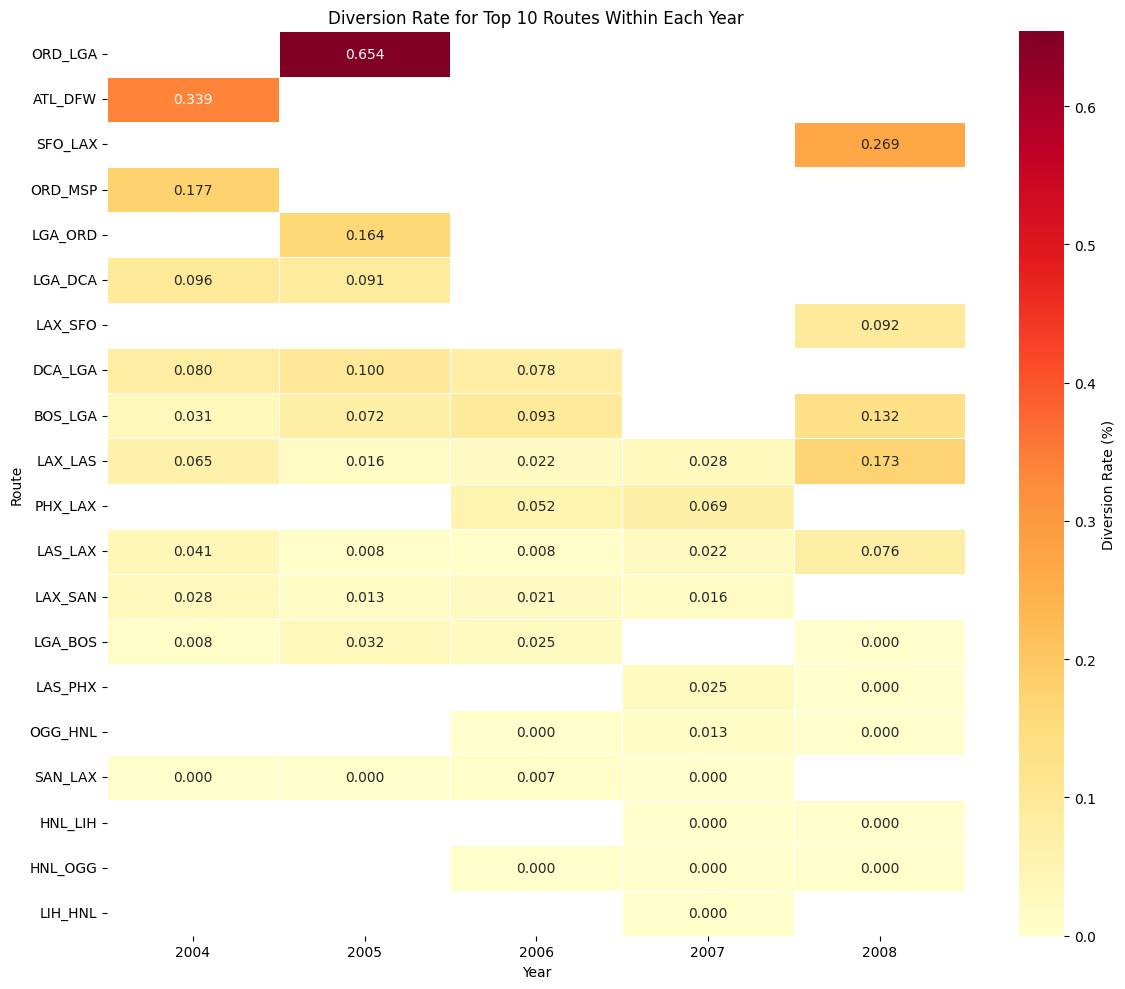

In [ ]:
# Keep only those year-route pairs
heatmap_source = route_summary.merge(
    top_ten_routes[["Year", "route"]],
    on=["Year", "route"],
    how="inner"
)

# Create one heatmap table:
# routes not in the top 10 for a given year will be NaN automatically
heatmap_df = heatmap_source.pivot(
    index="route",
    columns="Year",
    values="div_rate"
)

# Order routes by average diversion rate across years
route_order = heatmap_df.mean(axis=1).sort_values(ascending=False).index
heatmap_df = heatmap_df.reindex(route_order)

plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    heatmap_df,
    cmap="YlOrRd",
    linewidths=0.5,
    annot=True,
    fmt=".3f",
    cbar_kws={"label": "Diversion Rate (%)"}
)

ax.set_title("Diversion Rate for Top 10 Routes Within Each Year")
ax.set_xlabel("Year")
ax.set_ylabel("Route")

plt.tight_layout()
plt.show()

In [19]:
# filling na scheduled elapsed time values with median values of the flights with same route
div_df["CRSElapsedTime"] = div_df["CRSElapsedTime"].fillna(
    div_df.groupby("route")["CRSElapsedTime"].transform("median")
)

In [20]:
# Creating new distance_group column in div_df to help with filling up the rest of the na values with no route 
div_df["distance_group"] = pd.cut(
    div_df["Distance"],
    bins = [0, 250, 500, 1000, 1500, 2500, 5000],
    labels = [
        "0-250",
        "251-500",
        "501-1000",
        "1001-1500",
        "1501-2500",
        "2500+"
    ],
    include_lowest = True
)

In [21]:
# Filling the rest of the na values in scheduled elapsed time column with median value of their specific distance_group
div_df["CRSElapsedTime"] = div_df["CRSElapsedTime"].fillna(
    div_df.groupby("distance_group", observed = True)["CRSElapsedTime"].transform("median")
)

In [22]:
# Adding new columns to div_df for inclusion to model  
div_df["Dest_arr_hr"] = div_df["Dest"].astype(str) + "_" + div_df["crs_arr_hour"].astype(str)
div_df["Origin_dep_hr"] = div_df["Origin"].astype(str) + "_" + div_df["crs_dep_hour"].astype(str)


In [19]:
# Grouping data by year and scheduled arrival hour for arr_hour_df and year and scheduled departure hour for the dep_hour_df for plotting 
arr_hour_df = (
    div_df.groupby(["Year", "crs_arr_hour"], as_index = False)
    .agg(
        diversion_rate = ("Diverted", "mean"),
        n_flights = ("Diverted", "size")
    )
    .rename(columns = {"crs_arr_hour": "hour"})
)
arr_hour_df["feature"] = "Scheduled arrival hour"

dep_hour_df = (
    div_df.groupby(["Year", "crs_dep_hour"], as_index=False)
    .agg(diversion_rate = ("Diverted", "mean"),
         n_flights = ("Diverted", "size")
    )
    .rename(columns = {"crs_dep_hour": "hour"})
)
dep_hour_df["feature"] = "Scheduled departure hour"

hour_plot_df = pd.concat([arr_hour_df, dep_hour_df], ignore_index = True)

hour_plot_df["Year"] = hour_plot_df["Year"].astype(str)

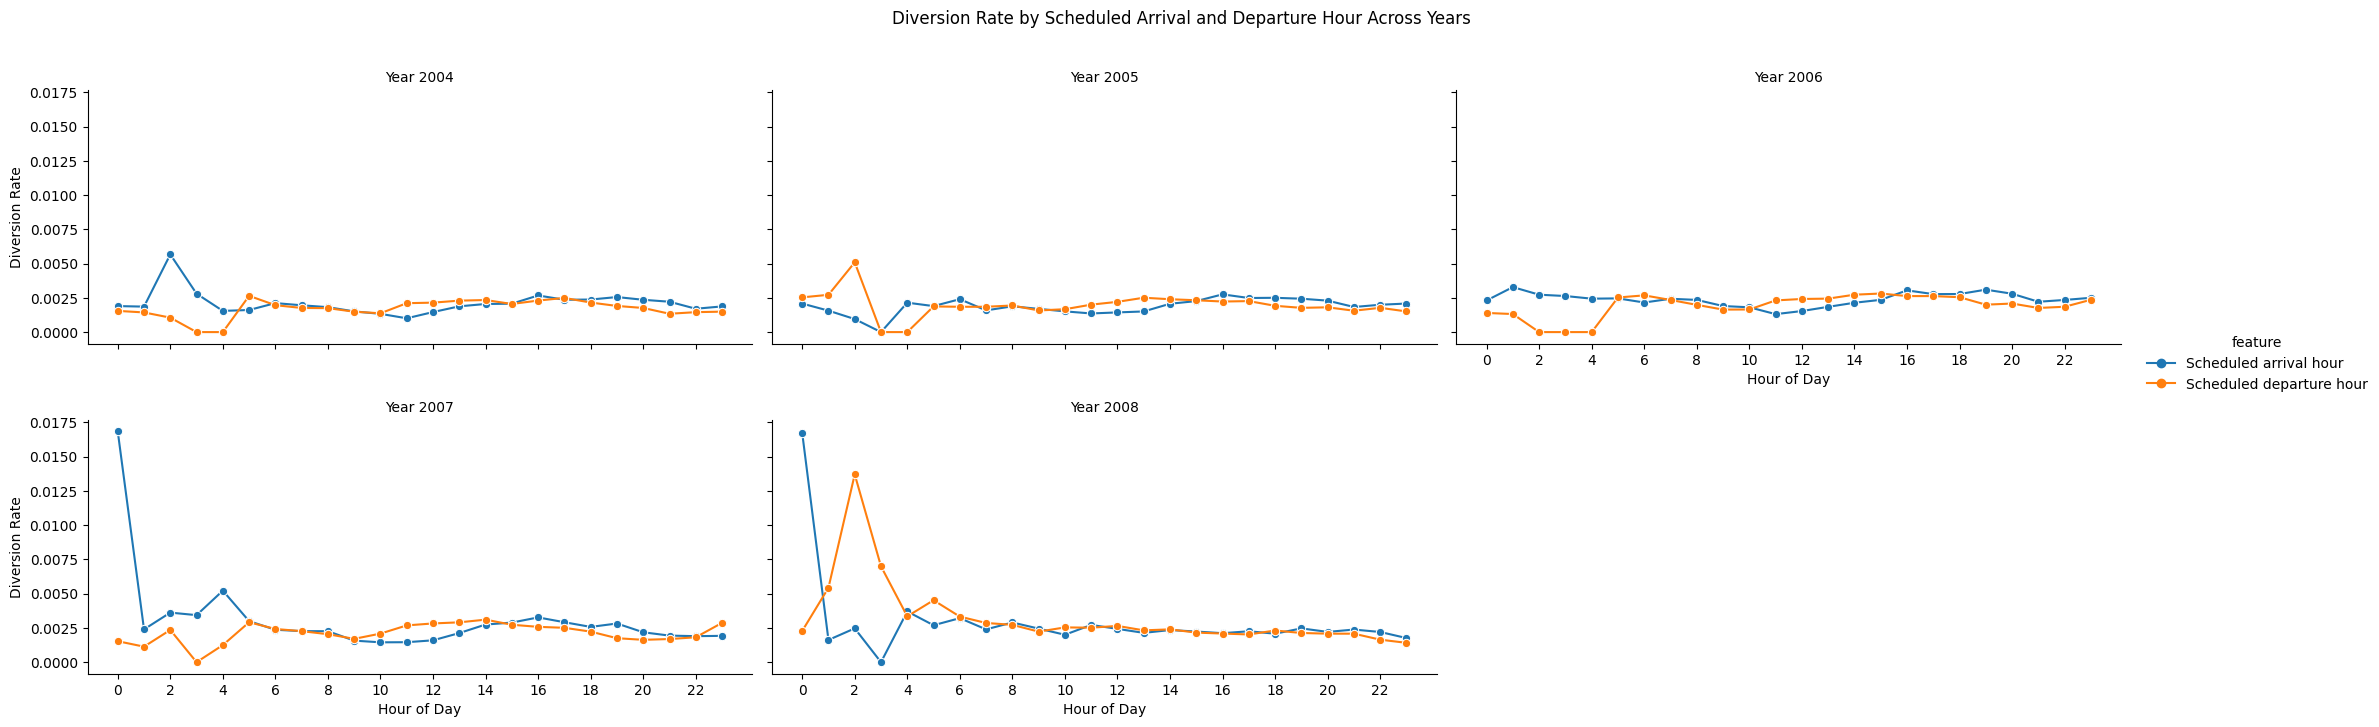

In [ ]:
# Plotting a line plot to show the diversion rate across the different scheduled departure and arrival hours over the years
g = sns.relplot(
    data=hour_plot_df,
    x="hour",
    y="diversion_rate",
    hue="feature",
    col="Year",
    kind="line",
    marker="o",
    col_wrap=3,
    height=4,
    aspect=1.8 
)

g.set_axis_labels("Hour of Day", "Diversion Rate")
g.set_titles("Year {col_name}")

for ax in g.axes.flat:
    ax.set_xticks(range(0, 24, 2))

g.fig.subplots_adjust(top=0.88, bottom=0.15, hspace=0.3)
g.fig.suptitle("Diversion Rate by Scheduled Arrival and Departure Hour Across Years")

plt.show()

In [23]:
# Creating empty historical route and destination columns for modelling (to be filled later with historical rates from div_df)
div_df["hist_route_div_rate_prev_years"] = np.nan
div_df["hist_dest_div_rate_prev_years"] = np.nan

In [24]:
# Calculating dest_arrival_volume for each month, DayofMonth, destination and scheduled arrival hr across the years 
dest_arrival_volume = (
    div_df.groupby(["Year", "Month", "DayofMonth", "Dest", "crs_arr_hour"])
    .size()
    .rename("dest_arrival_volume")
    .reset_index()
)

In [25]:
# Merging dest_arrival_volume into div_df
div_df = div_df.merge(
    dest_arrival_volume,
    on=["Year", "Month", "DayofMonth", "Dest", "crs_arr_hour"],
    how="left"
)

In [ ]:
# Mapping the flights to "Not Diverted" and "Diverted" and keeping year column as string data type
plot_df = div_df[["Year", "Diverted", "dest_arrival_volume"]].copy()
plot_df["Diverted_label"] = plot_df["Diverted"].map({0: "Not Diverted", 1: "Diverted"})
plot_df["Year"] = plot_df["Year"].astype(str)

In [ ]:
# Calculating median values
summary_df = (
    plot_df.groupby(["Year", "Diverted_label"], as_index=False)
    .agg(
        median_dest_arrival_volume=("dest_arrival_volume", "median"),
        n=("dest_arrival_volume", "size")
    )
)

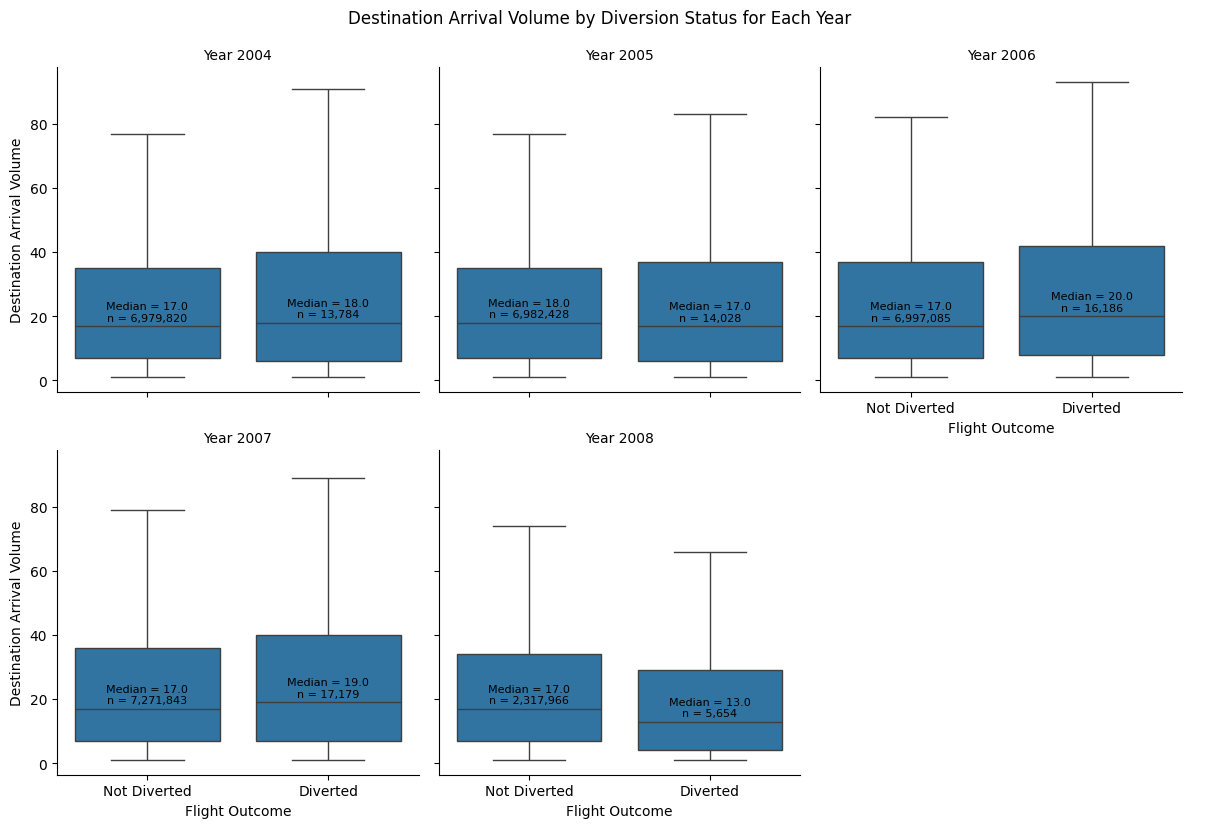

In [ ]:
# PLotting boxplots across years to show distribution of dest_arrival_volume for diverted and non-diverted flights 
g = sns.catplot(
    data=plot_df,
    x="Diverted_label",
    y="dest_arrival_volume",
    col="Year",
    kind="box",
    col_wrap=3,
    showfliers=False,
    sharey=True,
    height=4,
    aspect=1
)

g.set_axis_labels("Flight Outcome", "Destination Arrival Volume")
g.set_titles("Year {col_name}")

labels = ["Not Diverted", "Diverted"]

for ax, year in zip(g.axes.flat, sorted(plot_df["Year"].unique())):
    year_summary = summary_df[summary_df["Year"] == year]

    for i, label in enumerate(labels):
        row = year_summary[year_summary["Diverted_label"] == label]
        if not row.empty:
            median_val = row["median_dest_arrival_volume"].iloc[0]
            count_val = row["n"].iloc[0]

            ax.text(
                i,
                median_val + 1,
                f"Median = {median_val:.1f}\nn = {count_val:,}",
                ha="center",
                va="bottom",
                fontsize=8
            )

g.fig.suptitle("Destination Arrival Volume by Diversion Status for Each Year", y=1.03)
plt.show()

In [ ]:
# Perform yearly Mann-Whitney U tests to compare dest arrival volume btwn diverted and non-diverted flights, and store the summary statistics
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

mw_results = []

for year in sorted(div_df["Year"].dropna().unique()):
    year_df = div_df[div_df["Year"] == year]

    not_diverted = year_df.loc[
        year_df["Diverted"] == 0, "dest_arrival_volume"
    ].dropna()

    diverted = year_df.loc[
        year_df["Diverted"] == 1, "dest_arrival_volume"
    ].dropna()

    stat, p_value = mannwhitneyu(
        not_diverted,
        diverted,
        alternative="two-sided"
    )

    median_not_div = not_diverted.median()
    median_div = diverted.median()
    median_diff = median_div - median_not_div

    if p_value < 0.001:
        sig_label = "***"
    elif p_value < 0.01:
        sig_label = "**"
    elif p_value < 0.05:
        sig_label = "*"
    else:
        sig_label = "ns"

    mw_results.append({
        "Year": int(year),
        "Median_Not_Diverted": round(median_not_div, 2),
        "Median_Diverted": round(median_div, 2),
        "Median_Difference": round(median_diff, 2),
        "U_Statistic": round(stat, 2),
        "P_Value": p_value,
        "Significance": sig_label
    })

In [ ]:
# Saving the results into a dataframe, mv_results_df
mw_results_df = pd.DataFrame(mw_results)

# prettier p-value formatting
mw_results_df["P_Value"] = mw_results_df["P_Value"].apply(
    lambda x: f"{x:.3e}" if x < 0.001 else f"{x:.4f}"
)

mw_results_df["U_Statistic"] = mw_results_df["U_Statistic"].apply(lambda x: f"{x:,.0f}")

mw_results_df.columns = [
    "Year",
    "Median (Not Diverted)",
    "Median (Diverted)",
    "Median Difference",
    "U Statistic",
    "P-Value",
    "Significance"
]

mw_results_df

,Year,Median (Not Diverted),Median (Diverted),Median Difference,U Statistic,P-Value,Significance
0,2004,17.0,18.0,1.0,"48,003,660,928",0.6688,ns
1,2005,18.0,17.0,-1.0,"49,618,284,940",0.0071,**
2,2006,17.0,20.0,3.0,"54,191,307,760",2.748e-21,***
3,2007,17.0,19.0,2.0,"61,314,515,615",3.112e-05,***
4,2008,17.0,13.0,-4.0,"7,224,612,414",1.378e-40,***


In [26]:
# Importing libraries for model
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

In [27]:
# defining features for model
feature_cols = [
    "crs_arr_hour", # identify as categorical since time of day is cyclical, so hr 23 and hr 0 are close                          
    "crs_dep_hour",
    "carrier",
    "route",
    "Distance",
    "CRSElapsedTime",
    "hist_route_div_rate_prev_years",
    "hist_dest_div_rate_prev_years",
    "Dest_arr_hr",
    "Dest",
    "Origin",
    "Origin_dep_hr",
    "Month", # identify as categorical since no linear relationship between div rate across months
    "dest_arrival_volume"
]

In [28]:
# Keep only available columns
feature_cols = [col for col in feature_cols if col in div_df.columns]

In [29]:
# Identifying categorical features for preprocessing
categorical_features = [
    col for col in [
        "carrier", "crs_arr_hour", "crs_dep_hour", 
        "route", "Dest", "Dest_arr_hr",
        "Origin", "Origin_dep_hr", "Month"
    ]
    if col in feature_cols
]

In [30]:
# Identifying numerical features for preprocessing
numeric_features = [
    col for col in [
      "Distance", "CRSElapsedTime", "hist_route_div_rate_prev_years",
      "hist_dest_div_rate_prev_years", "dest_arrival_volume"
    ]
    if col in feature_cols
]

In [31]:
# One-hot encoding categorical features
categorical_transformer = Pipeline(steps = [
    ("onehot", OneHotEncoder(handle_unknown = "ignore"))
])

# Standardize numerical features
numeric_transformer = Pipeline(steps = [
    ("scaler", StandardScaler())
])

In [34]:
# Storing yearly evaluation metrics, trained models and permutation importance results
year_results = []
year_models = {}
year_importances = {}


Training model for Year 2004

Confusion Matrix:
[[1547629  546318]
 [   1761    2374]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.7391    0.8496   2093947
           1     0.0043    0.5741    0.0086      4135

    accuracy                         0.7388   2098082
   macro avg     0.5016    0.6566    0.4291   2098082
weighted avg     0.9969    0.7388    0.8479   2098082


Permutation Importance for Year 2004:
                           feature  importance_mean  importance_std
6   hist_route_div_rate_prev_years         0.012081        0.000034
13             dest_arrival_volume         0.005847        0.000180
9                             Dest         0.005756        0.000194
8                      Dest_arr_hr         0.005321        0.000270
3                            route         0.004873        0.000163
5                   CRSElapsedTime         0.004755        0.000097
4                         Distance         0.0

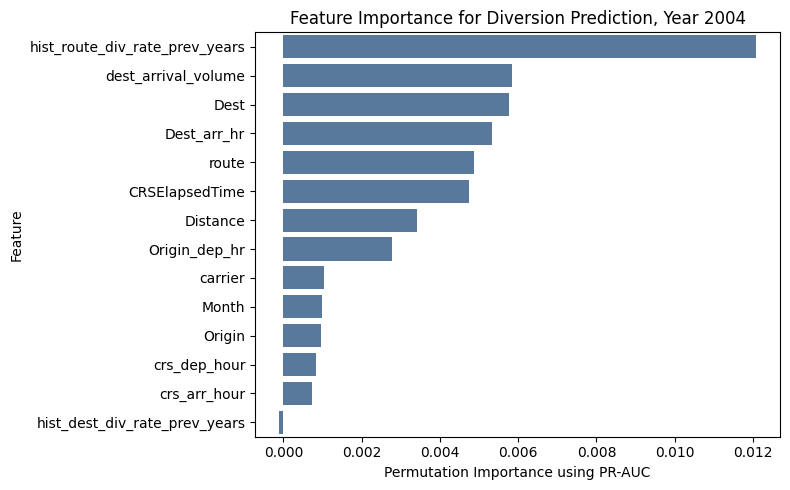


Training model for Year 2005

Confusion Matrix:
[[1562505  532224]
 [   1824    2384]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9988    0.7459    0.8540   2094729
           1     0.0045    0.5665    0.0088      4208

    accuracy                         0.7456   2098937
   macro avg     0.5016    0.6562    0.4314   2098937
weighted avg     0.9968    0.7456    0.8524   2098937


Permutation Importance for Year 2005:
                           feature  importance_mean  importance_std
6   hist_route_div_rate_prev_years         0.010334        0.000075
9                             Dest         0.008577        0.000221
13             dest_arrival_volume         0.008154        0.000115
8                      Dest_arr_hr         0.007419        0.000313
7    hist_dest_div_rate_prev_years         0.005905        0.000204
3                            route         0.005674        0.000603
11                   Origin_dep_hr         0.0

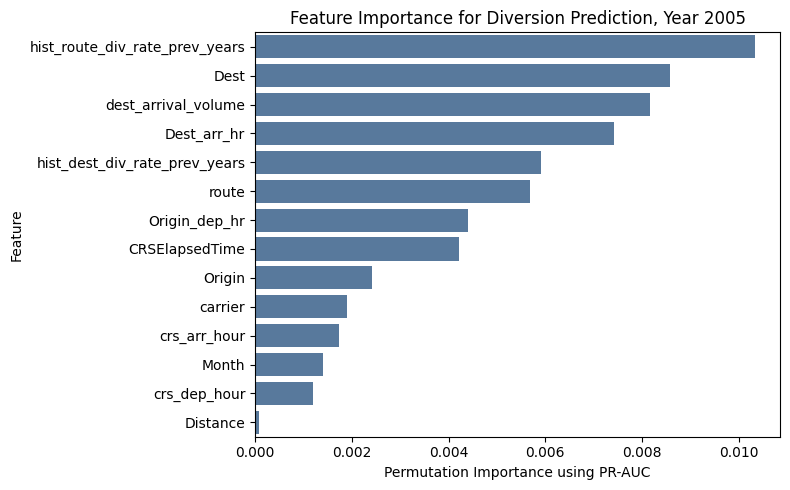


Training model for Year 2006

Confusion Matrix:
[[1543711  555415]
 [   1928    2928]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9988    0.7354    0.8471   2099126
           1     0.0052    0.6030    0.0104      4856

    accuracy                         0.7351   2103982
   macro avg     0.5020    0.6692    0.4287   2103982
weighted avg     0.9965    0.7351    0.8452   2103982


Permutation Importance for Year 2006:
                           feature  importance_mean  importance_std
4                         Distance         0.007895        0.000189
9                             Dest         0.006974        0.000099
13             dest_arrival_volume         0.006722        0.000037
6   hist_route_div_rate_prev_years         0.006112        0.000072
8                      Dest_arr_hr         0.006045        0.000105
7    hist_dest_div_rate_prev_years         0.004779        0.000106
3                            route         0.0

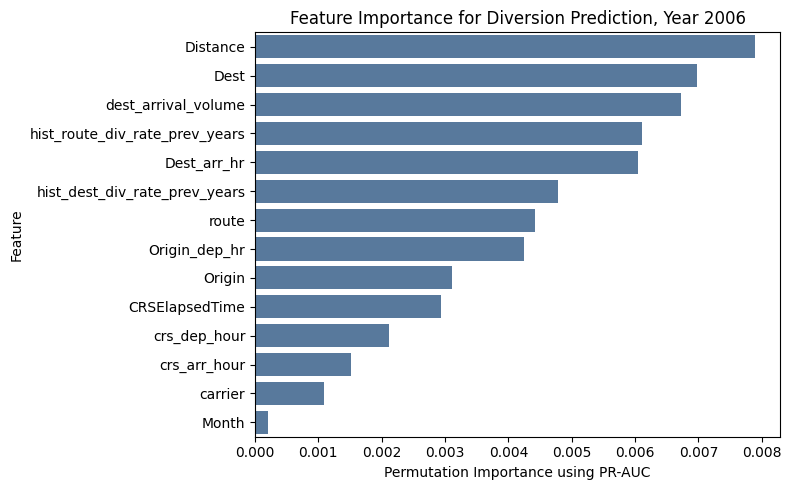


Training model for Year 2007

Confusion Matrix:
[[1641610  539943]
 [   1953    3201]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9988    0.7525    0.8583   2181553
           1     0.0059    0.6211    0.0117      5154

    accuracy                         0.7522   2186707
   macro avg     0.5024    0.6868    0.4350   2186707
weighted avg     0.9965    0.7522    0.8563   2186707


Permutation Importance for Year 2007:
                           feature  importance_mean  importance_std
4                         Distance         0.019093        0.000307
8                      Dest_arr_hr         0.019001        0.000121
9                             Dest         0.018051        0.000351
13             dest_arrival_volume         0.017950        0.000323
0                     crs_arr_hour         0.015369        0.000235
5                   CRSElapsedTime         0.014224        0.000138
3                            route         0.0

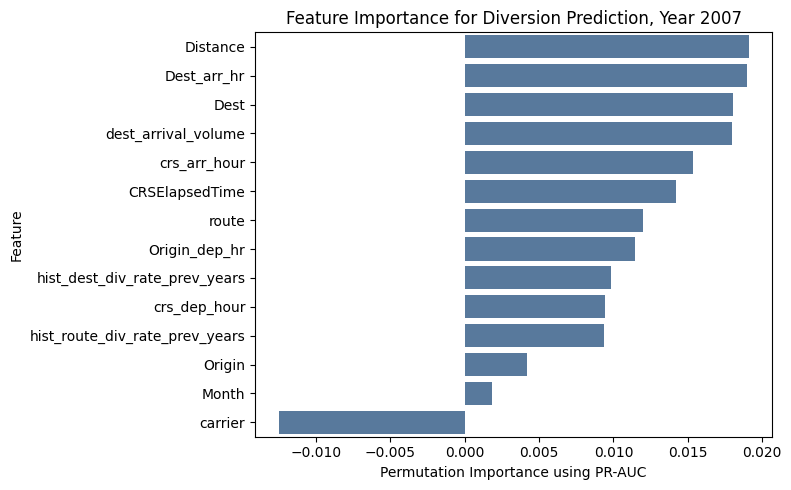


Training model for Year 2008

Confusion Matrix:
[[583789 111601]
 [   927    769]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9984    0.8395    0.9121    695390
           1     0.0068    0.4534    0.0135      1696

    accuracy                         0.8386    697086
   macro avg     0.5026    0.6465    0.4628    697086
weighted avg     0.9960    0.8386    0.9099    697086


Permutation Importance for Year 2008:
                           feature  importance_mean  importance_std
13             dest_arrival_volume         0.021046        0.000266
8                      Dest_arr_hr         0.017986        0.000250
9                             Dest         0.017053        0.001045
6   hist_route_div_rate_prev_years         0.015089        0.000450
0                     crs_arr_hour         0.014216        0.000412
3                            route         0.011005        0.000936
1                     crs_dep_hour         0.00811

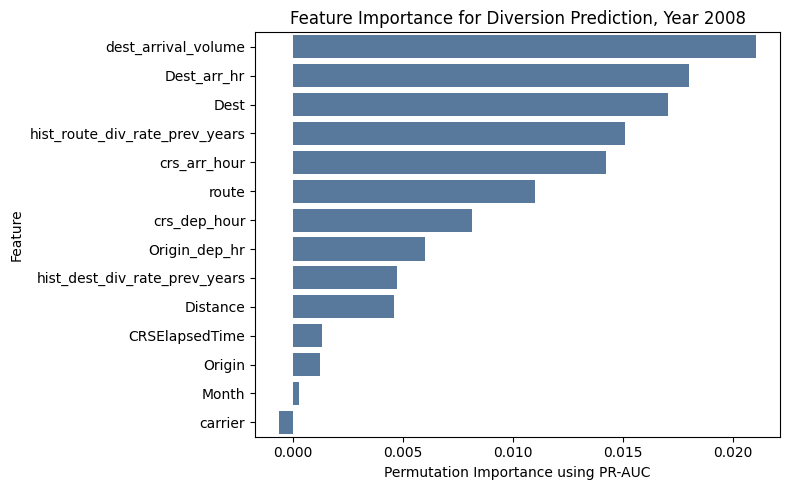

In [35]:
# Training and evaluating yearly logistic regression models 
import gc

smoothing = 100

for year in sorted(div_df["Year"].dropna().unique()):
    print(f"\n==============================")
    print(f"Training model for Year {int(year)}")
    print(f"==============================")

    year_model_df = div_df[div_df["Year"] == year].copy()

    X = year_model_df[feature_cols]
    y = year_model_df["Diverted"].astype(int)

    if y.nunique() < 2:
        print(f"Skipping {year}: only one target class available.")
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size = 0.3,
        random_state = 42,
        stratify = y
    )

 # Use only 2004 training data since there is no historical data for 2004
    if int(year) == 2004:
        fallback_rate = y_train.mean()
        
        route_div_flights = y_train.groupby(X_train["route"]).sum()
        route_total_flights = y_train.groupby(X_train["route"]).size()

        dest_div_flights = y_train.groupby(X_train["Dest"]).sum()
        dest_total_flights = y_train.groupby(X_train["Dest"]).size()

    # Use only previous years for later-year models
    else:
        prev_mask = div_df["Year"] < year
        fallback_rate = div_df.loc[prev_mask, "Diverted"].mean()

        route_div_flights = (
            div_df.loc[prev_mask]
            .groupby("route")["Diverted"]
            .sum()
        )

        route_total_flights = (
            div_df.loc[prev_mask]
            .groupby("route")["Diverted"]
            .size()
        )

        dest_div_flights = (
            div_df.loc[prev_mask]
            .groupby("Dest")["Diverted"]
            .sum()
        )

        dest_total_flights = (
            div_df.loc[prev_mask]
            .groupby("Dest")["Diverted"]
            .size()
        )

    route_rate_map = (
        (route_div_flights + smoothing * fallback_rate)
        /
        (route_total_flights + smoothing)
    )

    dest_rate_map = (
        (dest_div_flights + smoothing * fallback_rate)
        /
        (dest_total_flights + smoothing)
    )

    X_train.loc[:, "hist_route_div_rate_prev_years"] = (
        X_train["route"].map(route_rate_map).fillna(fallback_rate)
    )

    X_test.loc[:, "hist_route_div_rate_prev_years"] = (
        X_test["route"].map(route_rate_map).fillna(fallback_rate)
    )    
    
    X_train.loc[:, "hist_dest_div_rate_prev_years"] = (
        X_train["Dest"].map(dest_rate_map).fillna(fallback_rate)
    )

    X_test.loc[:, "hist_dest_div_rate_prev_years"] = (
        X_test["Dest"].map(dest_rate_map).fillna(fallback_rate)
    )  

    preprocessor = ColumnTransformer(transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features)
    ])

    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter = 2000, class_weight="balanced"))
    ])

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    # Evaluation for this year
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits = 4, zero_division = 0))

    pr_auc = average_precision_score(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)

    year_results.append({
        "Year": int(year),
        "precision": precision_score(y_test, y_pred, zero_division = 0),
        "recall": recall_score(y_test, y_pred, zero_division = 0),
        "f1": f1_score(y_test, y_pred, zero_division = 0),
        "pr_auc": pr_auc,
        "roc_auc": roc_auc
    })

    year_models[int(year)] = clf

    # Permutation importance for this year
    perm = permutation_importance(
        clf,
        X_test,
        y_test,
        scoring = "average_precision",
        n_repeats = 5,
        random_state = 42
    )

    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    year_importances[int(year)] = importance_df

    print(f"\nPermutation Importance for Year {int(year)}:")
    print(importance_df)

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data = importance_df,
        x = "importance_mean",
        y = "feature",
        color  ="#4c78a8"
    )
    plt.xlabel("Permutation Importance using PR-AUC")
    plt.ylabel("Feature")
    plt.title(f"Feature Importance for Diversion Prediction, Year {int(year)}")
    plt.tight_layout()
    plt.show()

    del (
        year_model_df, X, y, X_train, X_test, y_train, y_test,
        clf, y_pred, y_prob, perm, importance_df,
        route_div_flights, route_total_flights,
        dest_div_flights, dest_total_flights,
        route_rate_map, dest_rate_map
    )
    gc.collect()

In [38]:
# Saving Logisitc Regression model results into year_results_df
year_results_df = pd.DataFrame(year_results)

In [39]:
# Saving the year_results_df as a csv 
year_results_df.to_csv("logistic_results.csv", index = False)

In [ ]:
# Extract encoded categorical and numerical faatures names and logistic regression coef for each yearly model  
coef_rows = []

for year, clf in year_models.items():
    preprocessor = clf.named_steps["preprocessor"]
    log_reg = clf.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()
    coefs = log_reg.coef_[0]

    temp_df = pd.DataFrame({
        "Year": int(year),
        "encoded_feature": feature_names,
        "coefficient": coefs
    })

    coef_rows.append(temp_df)

# Combine coefficents from all years into coef_df for plotting
coef_df = pd.concat(coef_rows, ignore_index=True)
coef_df.head()

,Year,encoded_feature,coefficient
0,2004,cat__carrier_ATA Airlines d/b/a ATA,-2.166381
1,2004,cat__carrier_AirTran Airways Corporation,-0.143117
2,2004,cat__carrier_Alaska Airlines Inc.,-0.283568
3,2004,cat__carrier_America West Airlines Inc. (Merge...,-0.369280
4,2004,cat__carrier_American Airlines Inc.,-0.409905


In [ ]:
# Map categorical features names back to original feature groups 
prefix_map = [
    ("cat__Dest_arr_hr_", "Dest_arr_hr"),
    ("cat__Origin_dep_hr_", "Origin_dep_hr"),
    ("cat__crs_arr_hour_", "crs_arr_hour"),
    ("cat__crs_dep_hour_", "crs_dep_hour"),
    ("cat__carrier_", "carrier"),
    ("cat__route_", "route"),
    ("cat__Dest_", "Dest"),
    ("cat__Origin_", "Origin"),
    ("cat__Month_", "Month"),
]

# Assigning each encoded categorical feature to its corresponding feature group
def map_feature_group(encoded_name):
    if encoded_name.startswith("num__"):
        return encoded_name.replace("num__", "")
    
    for prefix, group_name in prefix_map:
        if encoded_name.startswith(prefix):
            return group_name

    return encoded_name

In [ ]:
# Grouping categorical and numeric coefficient names into original features
coef_df["feature_group"] = coef_df["encoded_feature"].apply(map_feature_group)

In [ ]:
# Defining function for plotting ridgline of each categorical feature across the years
import seaborn as sns
import matplotlib.pyplot as plt

def plot_categorical_kde(feature_name):
    plot_df = coef_df[coef_df["feature_group"] == feature_name].copy()

    if plot_df.empty:
        print(f"No coefficients found for feature group: {feature_name}")
        return

    plot_df["Year"] = plot_df["Year"].astype(str)
    plot_df = plot_df.reset_index(drop=True)

    g = sns.FacetGrid(plot_df, row="Year", hue="Year", aspect=6, height=1.2)

    g.map_dataframe(
        sns.kdeplot,
        x="coefficient",
        fill=True,
        alpha=0.7
    )

    g.set_titles(row_template="{row_name}")
    g.set_xlabels("Coefficient Value")
    g.set_ylabels("")
    g.fig.suptitle(f"Coefficient Distribution Across Years: {feature_name}", y=1.02)
    plt.show()

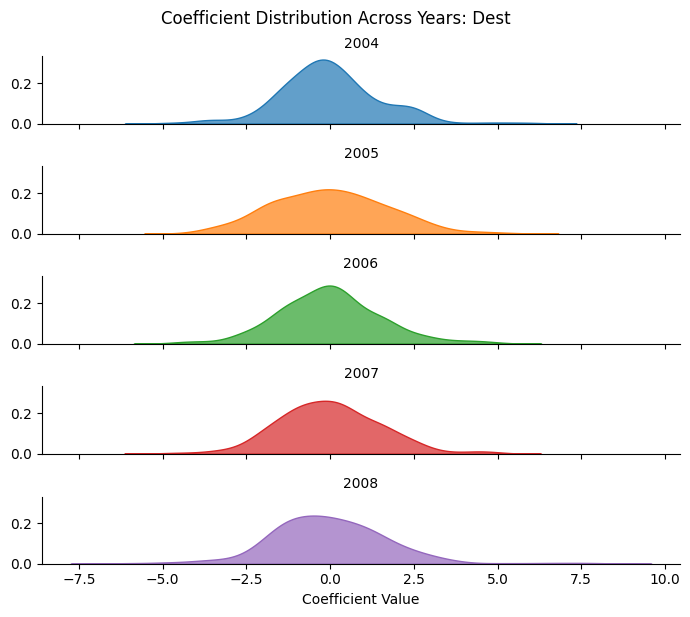

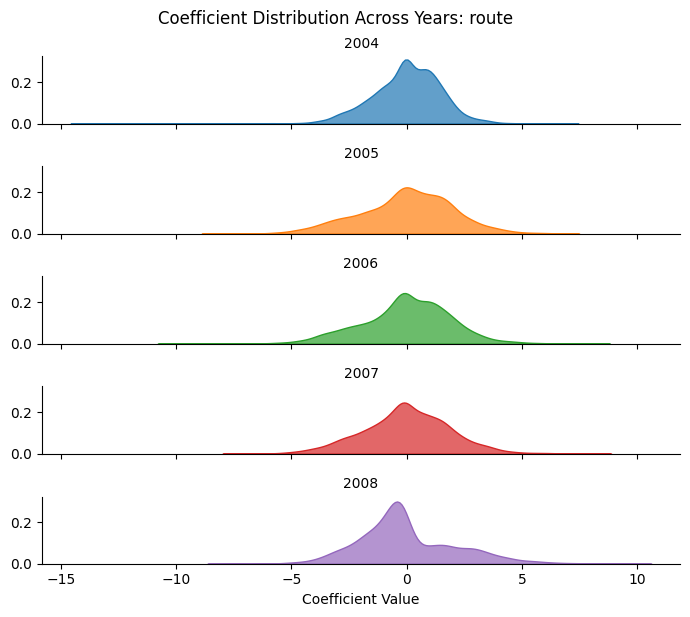

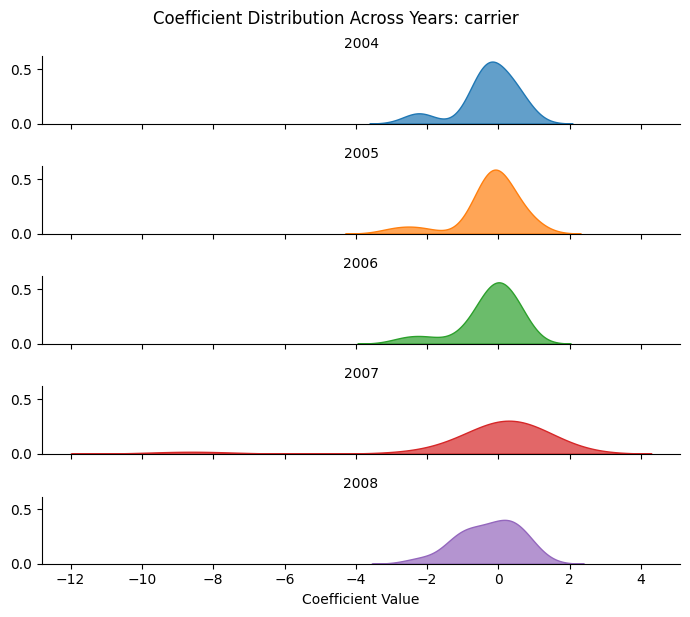

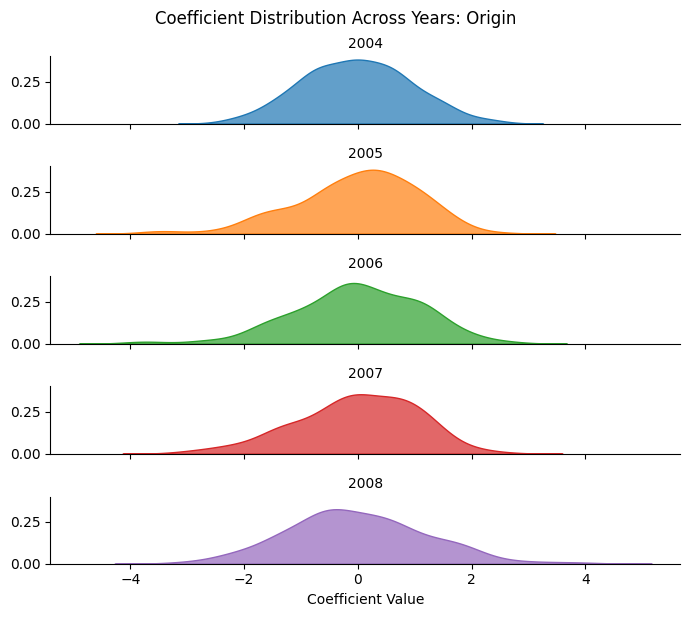

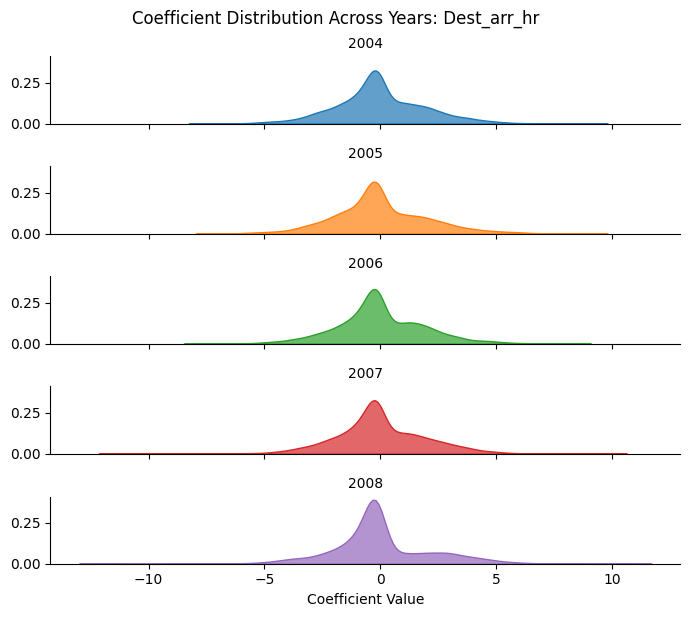

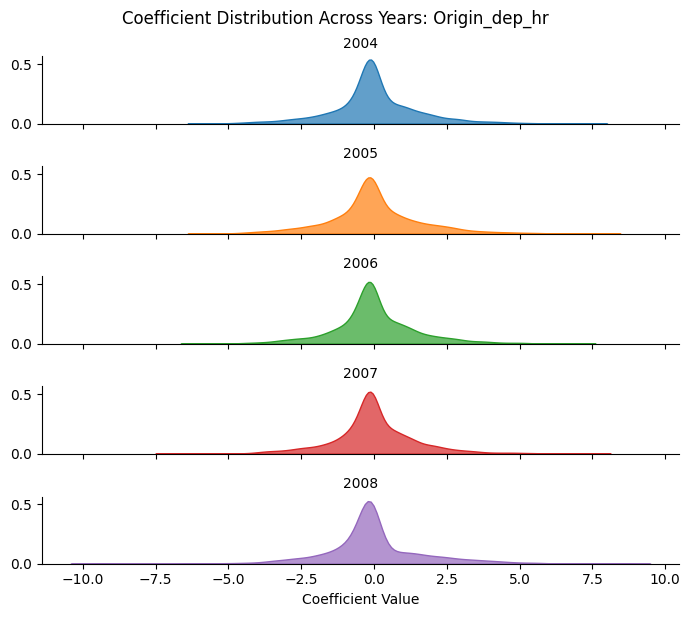

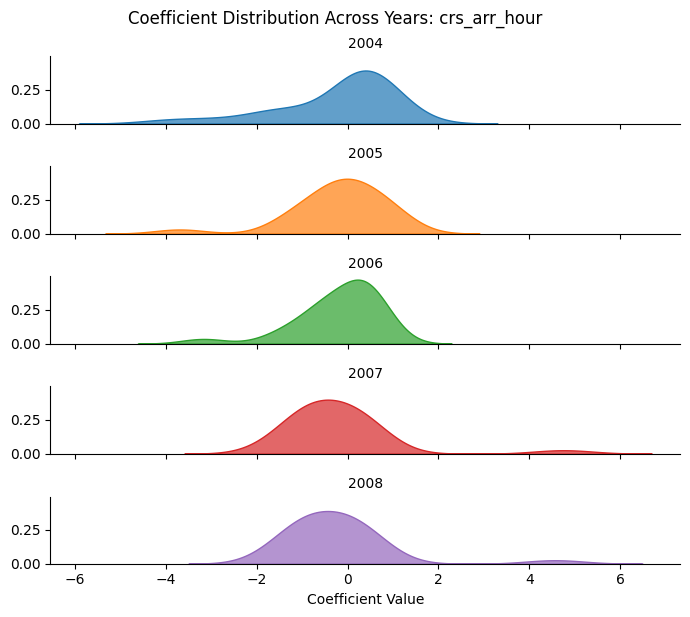

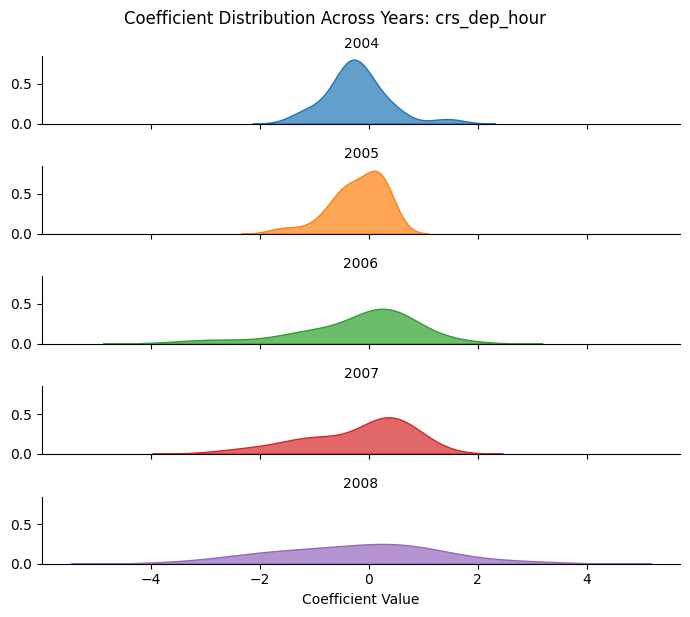

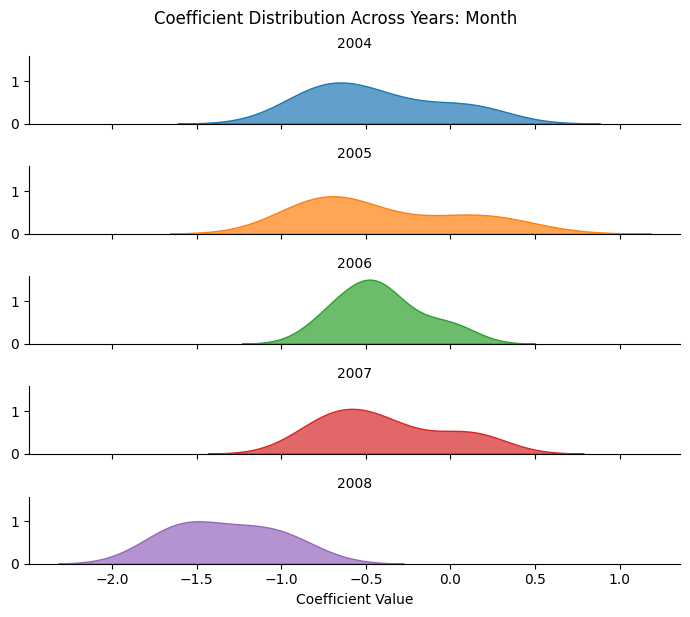

In [ ]:
# Plotting ridgeline plot for categorical features 
plot_categorical_kde("Dest")
plot_categorical_kde("route")
plot_categorical_kde("carrier")
plot_categorical_kde("Origin")
plot_categorical_kde("Dest_arr_hr")
plot_categorical_kde("Origin_dep_hr")
plot_categorical_kde("crs_arr_hour")
plot_categorical_kde("crs_dep_hour")
plot_categorical_kde("Month") 

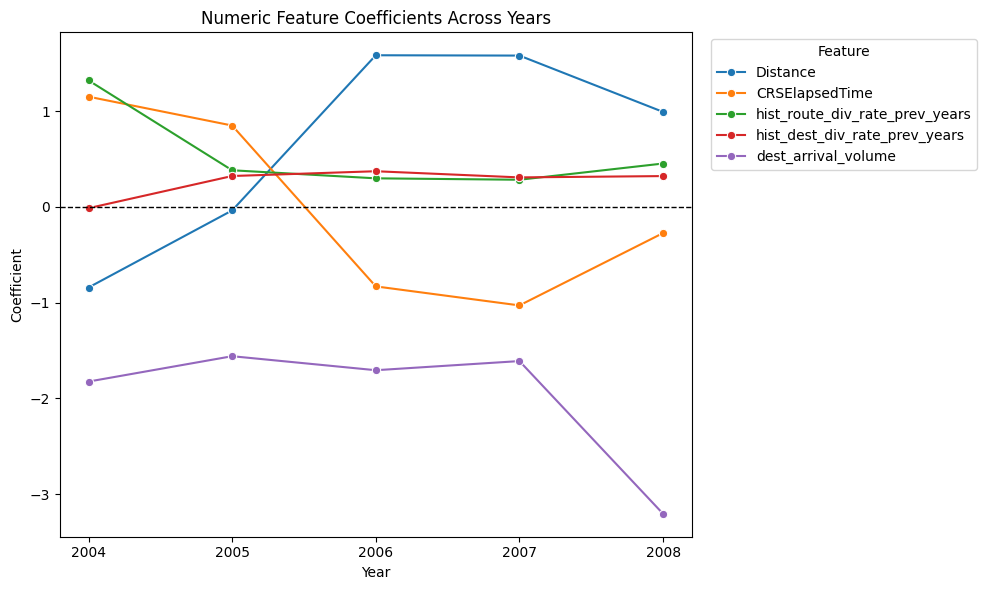

In [ ]:
# Plotting line plot for coefficients of numeric features
numeric_coef_df = coef_df[coef_df["feature_group"].isin(numeric_features)].copy()

numeric_coef_df["Year"] = numeric_coef_df["Year"].astype(str)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=numeric_coef_df,
    x="Year",
    y="coefficient",
    hue="feature_group",
    marker="o"
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Numeric Feature Coefficients Across Years")
plt.ylabel("Coefficient")
plt.xlabel("Year")
plt.legend(title="Feature", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Training CatBoost for Year 2004
0:	learn: 0.7920321	total: 5.09s	remaining: 42m 20s
100:	learn: 0.7990715	total: 6m 10s	remaining: 24m 25s
200:	learn: 0.8150314	total: 12m 41s	remaining: 18m 52s
300:	learn: 0.8255860	total: 19m 20s	remaining: 12m 47s
400:	learn: 0.8419000	total: 26m 34s	remaining: 6m 33s
499:	learn: 0.8533676	total: 33m 52s	remaining: 0us

Confusion Matrix:
[[1553714  540233]
 [   1479    2656]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9990    0.7420    0.8516   2093947
           1     0.0049    0.6423    0.0097      4135

    accuracy                         0.7418   2098082
   macro avg     0.5020    0.6922    0.4306   2098082
weighted avg     0.9971    0.7418    0.8499   2098082


Permutation Importance for CatBoost Year 2004:
                           feature  importance_mean  importance_std
13             dest_arrival_volume         0.029887        0.000750
8                      Dest_arr_hr         0.029

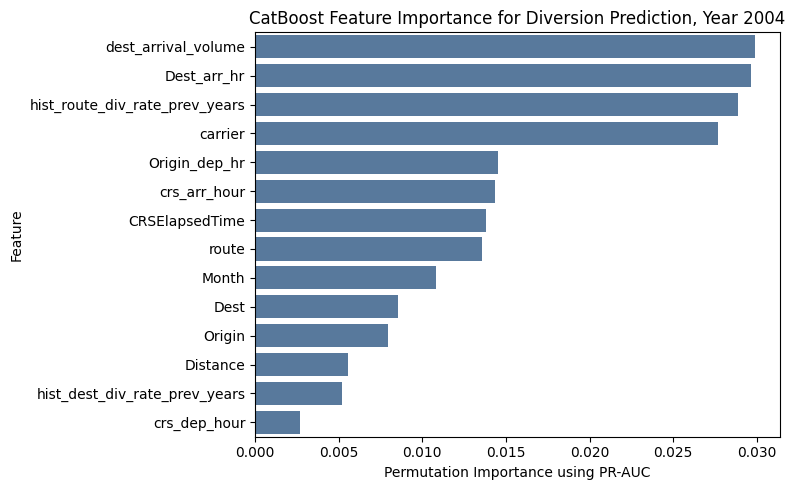


Training CatBoost for Year 2005
0:	learn: 0.6614541	total: 5.53s	remaining: 46m 1s
100:	learn: 0.7584539	total: 7m 25s	remaining: 29m 21s
200:	learn: 0.7829768	total: 14m 23s	remaining: 21m 24s
300:	learn: 0.7976184	total: 21m 28s	remaining: 14m 12s
400:	learn: 0.8177343	total: 29m 8s	remaining: 7m 11s
499:	learn: 0.8317083	total: 37m 2s	remaining: 0us

Confusion Matrix:
[[1598136  496593]
 [   1392    2816]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9991    0.7629    0.8652   2094729
           1     0.0056    0.6692    0.0112      4208

    accuracy                         0.7627   2098937
   macro avg     0.5024    0.7161    0.4382   2098937
weighted avg     0.9971    0.7627    0.8635   2098937


Permutation Importance for CatBoost Year 2005:
                           feature  importance_mean  importance_std
13             dest_arrival_volume         0.042942        0.000809
8                      Dest_arr_hr         0.029066

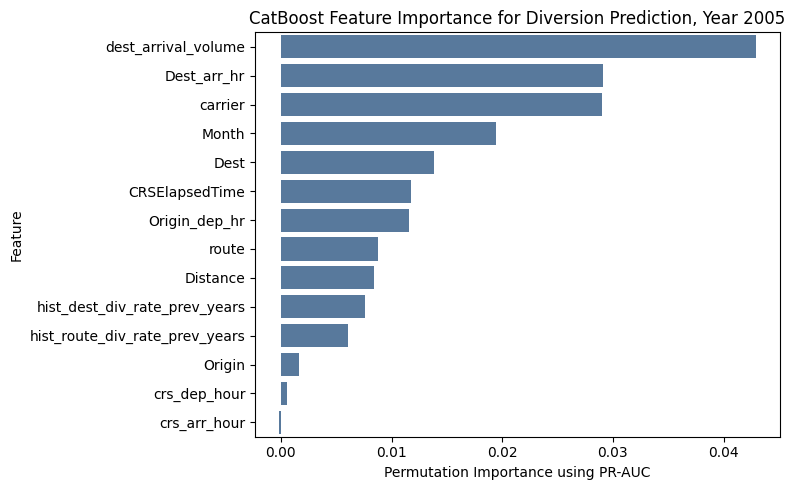


Training CatBoost for Year 2006
0:	learn: 0.6961526	total: 4.66s	remaining: 38m 44s
100:	learn: 0.7652636	total: 7m 16s	remaining: 28m 45s
200:	learn: 0.7869179	total: 14m 19s	remaining: 21m 18s
300:	learn: 0.8002820	total: 20m 49s	remaining: 13m 45s
400:	learn: 0.8179657	total: 28m 31s	remaining: 7m 2s
499:	learn: 0.8316486	total: 36m 17s	remaining: 0us

Confusion Matrix:
[[1613303  485823]
 [   1616    3240]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9990    0.7686    0.8688   2099126
           1     0.0066    0.6672    0.0131      4856

    accuracy                         0.7683   2103982
   macro avg     0.5028    0.7179    0.4409   2103982
weighted avg     0.9967    0.7683    0.8668   2103982


Permutation Importance for CatBoost Year 2006:
                           feature  importance_mean  importance_std
5                   CRSElapsedTime         0.056207        0.000227
13             dest_arrival_volume         0.0447

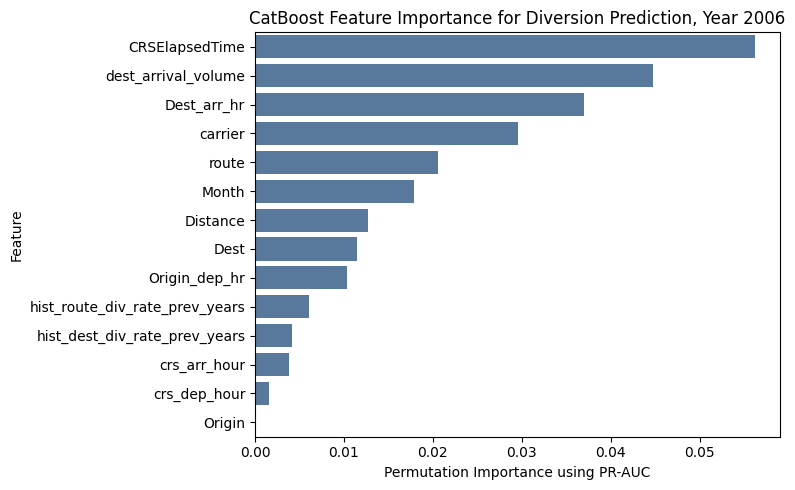


Training CatBoost for Year 2007
0:	learn: 0.7200058	total: 6.39s	remaining: 53m 8s
100:	learn: 0.7997322	total: 7m 58s	remaining: 31m 29s
200:	learn: 0.8212177	total: 17m 49s	remaining: 26m 31s
300:	learn: 0.8341769	total: 35m 59s	remaining: 23m 47s
400:	learn: 0.8504857	total: 1h 7m 16s	remaining: 16m 36s
499:	learn: 0.8622885	total: 1h 41m 52s	remaining: 0us

Confusion Matrix:
[[1753353  428200]
 [   1589    3565]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9991    0.8037    0.8908   2181553
           1     0.0083    0.6917    0.0163      5154

    accuracy                         0.8035   2186707
   macro avg     0.5037    0.7477    0.4536   2186707
weighted avg     0.9968    0.8035    0.8888   2186707


Permutation Importance for CatBoost Year 2007:
                           feature  importance_mean  importance_std
5                   CRSElapsedTime         0.129089        0.001051
2                          carrier         

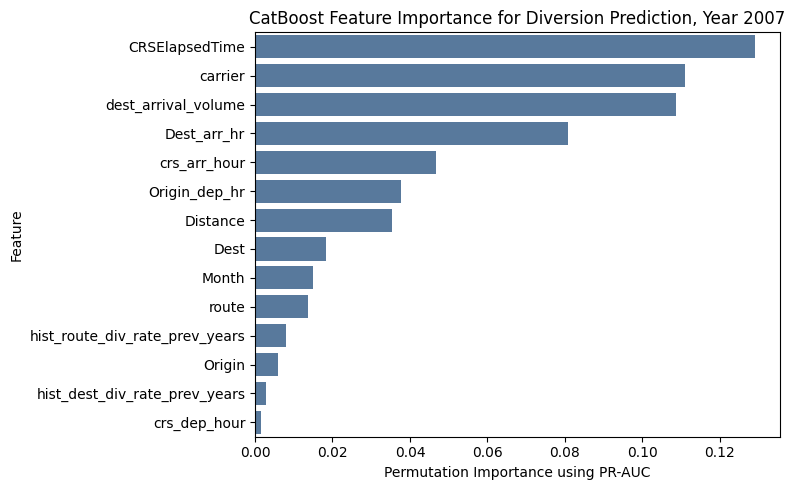


Training CatBoost for Year 2008
0:	learn: 0.7322240	total: 3.47s	remaining: 28m 49s
100:	learn: 0.7985674	total: 5m 18s	remaining: 20m 59s
200:	learn: 0.8230754	total: 11m 28s	remaining: 17m 4s
300:	learn: 0.8410283	total: 20m 24s	remaining: 13m 29s
400:	learn: 0.8727974	total: 29m 35s	remaining: 7m 18s
499:	learn: 0.8928749	total: 38m 49s	remaining: 0us

Confusion Matrix:
[[575105 120285]
 [   594   1102]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9990    0.8270    0.9049    695390
           1     0.0091    0.6498    0.0179      1696

    accuracy                         0.8266    697086
   macro avg     0.5040    0.7384    0.4614    697086
weighted avg     0.9966    0.8266    0.9027    697086


Permutation Importance for CatBoost Year 2008:
                           feature  importance_mean  importance_std
13             dest_arrival_volume         0.100179        0.003384
0                     crs_arr_hour         0.069714  

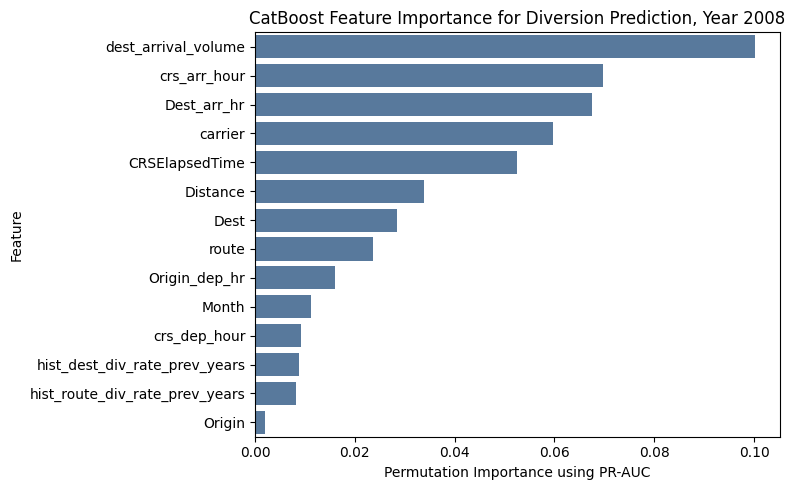

In [32]:
# Running Catboost model with same features for better identification of flight diversions (precision & recall) 
cat_year_results = {}
cat_year_models = {}
cat_year_importances = {}

from catboost import CatBoostClassifier

for year in sorted(div_df["Year"].dropna().unique()):
    print(f"\n==============================")
    print(f"Training CatBoost for Year {int(year)}")
    print(f"==============================")

    year_model_df = div_df[div_df["Year"] == year].copy()

    X = year_model_df[feature_cols].copy()
    y = year_model_df["Diverted"].astype(int)

    if y.nunique() < 2:
        print(f"Skipping {year}: only one target class available.")
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    smoothing = 100

    if int(year) == 2004:
        fallback_rate = y_train.mean()

        route_div_flights = y_train.groupby(X_train["route"]).sum()
        route_total_flights = y_train.groupby(X_train["route"]).size()

        dest_div_flights = y_train.groupby(X_train["Dest"]).sum()
        dest_total_flights = y_train.groupby(X_train["Dest"]).size()

    else:
        prev_mask = div_df["Year"] < year
        fallback_rate = div_df.loc[prev_mask, "Diverted"].mean()

        route_div_flights = (
            div_df.loc[prev_mask]
            .groupby("route")["Diverted"]
            .sum()
        )

        route_total_flights = (
            div_df.loc[prev_mask]
            .groupby("route")["Diverted"]
            .size()
        )

        dest_div_flights = (
            div_df.loc[prev_mask]
            .groupby("Dest")["Diverted"]
            .sum()
        )

        dest_total_flights = (
            div_df.loc[prev_mask]
            .groupby("Dest")["Diverted"]
            .size()
        )

    route_rate_map = (
        (route_div_flights + smoothing * fallback_rate)
        /
        (route_total_flights + smoothing)
    )

    dest_rate_map = (
        (dest_div_flights + smoothing * fallback_rate)
        /
        (dest_total_flights + smoothing)
    )

    X_train.loc[:, "hist_route_div_rate_prev_years"] = (
        X_train["route"].map(route_rate_map).fillna(fallback_rate)
    )
    X_test.loc[:, "hist_route_div_rate_prev_years"] = (
        X_test["route"].map(route_rate_map).fillna(fallback_rate)
    )

    X_train.loc[:, "hist_dest_div_rate_prev_years"] = (
        X_train["Dest"].map(dest_rate_map).fillna(fallback_rate)
    )
    X_test.loc[:, "hist_dest_div_rate_prev_years"] = (
        X_test["Dest"].map(dest_rate_map).fillna(fallback_rate)
    )

    cat_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="PRAUC",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=100
    )

    cat_model.fit(
        X_train,
        y_train,
        cat_features=categorical_features
    )

    y_prob = cat_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

    pr_auc = average_precision_score(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)

    cat_year_results[int(year)] = {
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "pr_auc": pr_auc,
        "roc_auc": roc_auc
    }

    # Permutation importance using PR-AUC
    perm = permutation_importance(
        cat_model,
        X_test,
        y_test,
        scoring = "average_precision",
        n_repeats = 5,
        random_state = 42,
        n_jobs = -1
    )

    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending = False)

    cat_year_importances[int(year)] = importance_df

    print(f"\nPermutation Importance for CatBoost Year {int(year)}:")
    print(importance_df)

    plt.figure(figsize = (8, 5))
    sns.barplot(
        data = importance_df,
        x = "importance_mean",
        y = "feature",
        color = "#4c78a8"
    )
    plt.xlabel("Permutation Importance using PR-AUC")
    plt.ylabel("Feature")
    plt.title(f"CatBoost Feature Importance for Diversion Prediction, Year {int(year)}")
    plt.tight_layout()
    plt.show()

    del X, y, X_train, X_test, y_train, y_test, cat_model, y_prob, y_pred, year_model_df, importance_df, perm

    import gc
    gc.collect()

In [41]:
# Saving cat_year_results into cat_results_df
cat_results_df = (
    pd.DataFrame.from_dict(cat_year_results, orient="index")
    .reset_index()
    .rename(columns={"index": "Year"})
)

cat_results_df["Year"] = cat_results_df["Year"].astype(int)
cat_results_df

,Year,precision,recall,f1,pr_auc,roc_auc
0,2004,0.004892,0.642322,0.009711,0.048600,0.755008
1,2005,0.005639,0.669202,0.011183,0.056147,0.799096
2,2006,0.006625,0.667216,0.013120,0.067481,0.800447
3,2007,0.008257,0.691696,0.016319,0.162479,0.837008
4,2008,0.009078,0.649764,0.017907,0.132272,0.822488


In [42]:
# SAving the catboost model results into a csv file
cat_results_df.to_csv("catboost_results.csv", index=False)

In [12]:
# Reading results of models 
logistic_results_df = pd.read_csv("logistic_results.csv")
cat_results_df = pd.read_csv("catboost_results.csv")

In [ ]:
# Merging result tables for plotting
comparison_df = logistic_results_df.rename(columns = {
    "precision": "Logistic Precision",
    "recall": "Logistic Recall",
    "f1": "Logistic F1",
    "pr_auc": "Logistic PR-AUC"
}).merge(
    cat_results_df.rename(columns = {
        "precision": "CatBoost Precision",
        "recall": "CatBoost Recall",
        "f1": "CatBoost F1",
        "pr_auc": "CatBoost PR-AUC"
    }),
    on = "Year",
    how = "inner"
)

In [15]:
# Loading baseline diversion rates across years into dictionary 
baseline_rates = (
    div_summary.set_index("Year")["div_percent"] / 100
).to_dict()

In [17]:
# Mapping baseline rates to each year in comparison_df and calculating PR_AUC lift for each model
comparison_df["Baseline Rate"] = comparison_df["Year"].map(baseline_rates)

comparison_df["Logistic PR-AUC Lift"] = (
    comparison_df["Logistic PR-AUC"] / comparison_df["Baseline Rate"]
)

comparison_df["CatBoost PR-AUC Lift"] = (
    comparison_df["CatBoost PR-AUC"] / comparison_df["Baseline Rate"]
)

In [18]:
# Formatting presentation of values of PR_AUC lift 
comparison_df["Logistic PR-AUC Lift"] = comparison_df["Logistic PR-AUC Lift"].map(lambda x: f"{x:.1f}x")
comparison_df["CatBoost PR-AUC Lift"] = comparison_df["CatBoost PR-AUC Lift"].map(lambda x: f"{x:.1f}x")

In [19]:
# Defining column names for clean plotting of table 
comparison_df = comparison_df[[
    "Year",
    "Baseline Rate",
    "Logistic Recall",
    "CatBoost Recall",
    "Logistic Precision",
    "CatBoost Precision",
    "Logistic PR-AUC",
    "Logistic PR-AUC Lift",
    "CatBoost PR-AUC",
    "CatBoost PR-AUC Lift"
]]

In [ ]:
# Renaming columns names and rounding off values to 4dp for cleaner table
comparison_df = comparison_df.rename(columns = {
    "Baseline Diversion Rate": "Base Rate",
    "Logistic Recall": "LR Recall",
    "CatBoost Recall": "CB Recall",
    "Logistic Precision": "LR Prec",
    "CatBoost Precision": "CB Prec",
    "Logistic PR-AUC": "LR PR-AUC",
    "Logistic PR-AUC Lift": "LR Lift",
    "CatBoost PR-AUC": "CB PR-AUC",
    "CatBoost PR-AUC Lift": "CB Lift"
})

comparison_df = comparison_df.round(4)

comparison_df

,Year,Base Rate,LR Recall,CB Recall,LR Prec,CB Prec,LR PR-AUC,LR PR-AUC Lift,CB PR-AUC,CB PR-AUC Lift
0,2004,0.0020,0.5741,0.6423,0.0043,0.0049,0.0148,7.5x,0.0486,24.7x
1,2005,0.0020,0.5665,0.6692,0.0045,0.0056,0.0155,7.7x,0.0561,28.0x
2,2006,0.0023,0.6030,0.6672,0.0052,0.0066,0.0131,5.7x,0.0675,29.2x
3,2007,0.0024,0.6211,0.6917,0.0059,0.0083,0.0255,10.8x,0.1625,68.9x
4,2008,0.0024,0.4534,0.6498,0.0068,0.0091,0.0254,10.4x,0.1323,54.4x
